<a href="https://colab.research.google.com/github/bhaskar-025/ML-BASIC-PROJECT/blob/CNN_MINI_PROJECT/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import zipfile

# Extract test.csv from test.csv.zip
with zipfile.ZipFile('/content/test.csv.zip', 'r') as zip_ref:
    zip_ref.extract('test.csv', '/content/')

# Extract train.csv from train.csv.zip
with zipfile.ZipFile('/content/train.csv.zip', 'r') as zip_ref:
    zip_ref.extract('train.csv', '/content/')

print('Successfully extracted test.csv and train.csv to /content/')


Successfully extracted test.csv and train.csv to /content/


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [9]:

df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [10]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df.shape

(42000, 785)

In [12]:
# Train
X_train = df.drop("label", axis=1).values
y_train = df["label"].values

# Test
X_test = df_test.values   # label drop mat karo

In [13]:
print(df_test.columns)

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)


In [14]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [15]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [16]:


y_train_cat = to_categorical(y_train, 10)


In [17]:
    perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [18]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])


In [19]:
history_percp = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,   # 20% of training data used for validation
    verbose=1
)


Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7780 - loss: 0.9577 - val_accuracy: 0.8599 - val_loss: 0.5976
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8667 - loss: 0.5328 - val_accuracy: 0.8786 - val_loss: 0.4778
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8800 - loss: 0.4567 - val_accuracy: 0.8873 - val_loss: 0.4289
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8874 - loss: 0.4193 - val_accuracy: 0.8946 - val_loss: 0.4019
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8926 - loss: 0.3961 - val_accuracy: 0.8974 - val_loss: 0.3824


In [20]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [21]:
ann.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])


In [22]:
ann_percp = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,   # 20% of training data used for validation
    verbose=1
)


Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7724 - loss: 0.8692 - val_accuracy: 0.8836 - val_loss: 0.4222
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8960 - loss: 0.3644 - val_accuracy: 0.9076 - val_loss: 0.3235
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9136 - loss: 0.2984 - val_accuracy: 0.9217 - val_loss: 0.2771
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9248 - loss: 0.2620 - val_accuracy: 0.9319 - val_loss: 0.2453
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9328 - loss: 0.2354 - val_accuracy: 0.9367 - val_loss: 0.2242


In [23]:

X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [24]:

cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [25]:
cnn.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [26]:
history_cnn = cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.7355 - loss: 0.8354 - val_accuracy: 0.9323 - val_loss: 0.2434
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.9086 - loss: 0.3068 - val_accuracy: 0.9537 - val_loss: 0.1552
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.9324 - loss: 0.2217 - val_accuracy: 0.9639 - val_loss: 0.1240
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.9448 - loss: 0.1805 - val_accuracy: 0.9661 - val_loss: 0.1101
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.9543 - loss: 0.1543 - val_accuracy: 0.9717 - val_loss: 0.0865


In [27]:


def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

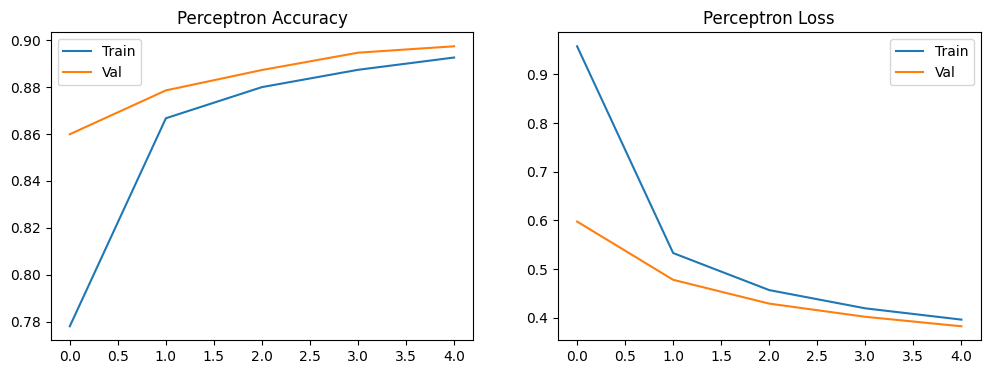

In [28]:
plot_training(history_percp, "Perceptron")

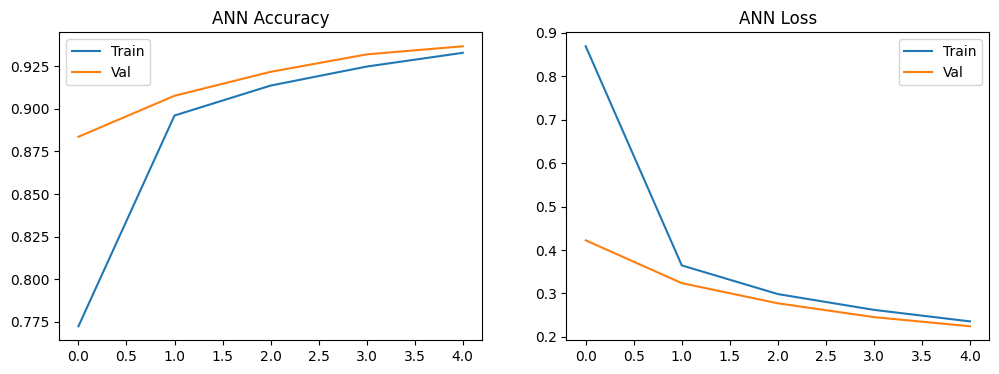

In [29]:
plot_training(ann_percp, "ANN")

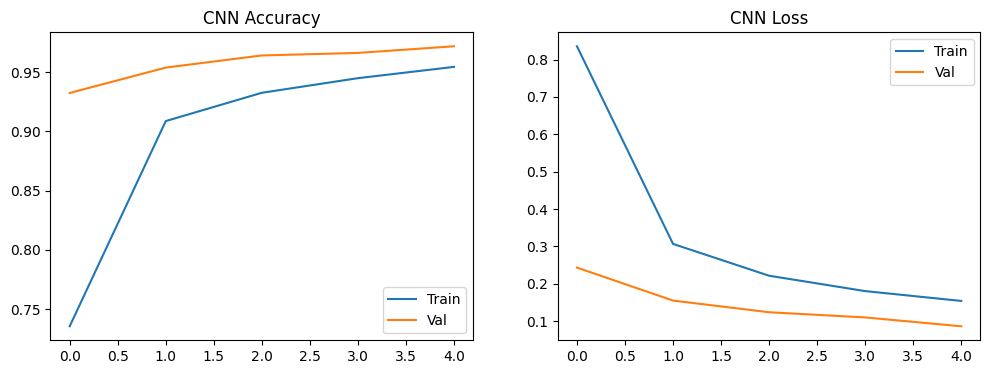

In [30]:

plot_training(history_cnn, "CNN")

In [31]:
def show_side_by_side(models, model_names, X, X_cnn, y_true=None, n=10):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if y_true is not None:
            plt.title(f"True: {y_true[idx]}")
        else:
            plt.title("True: N/A")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

In [32]:
y_test = None

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

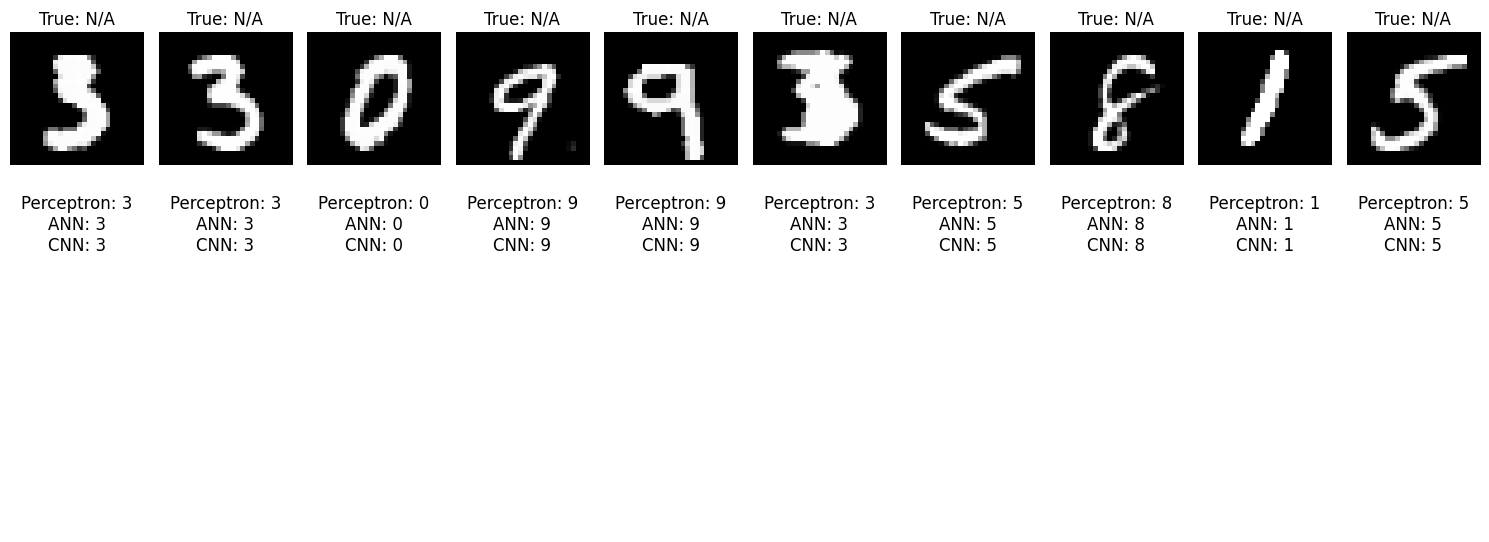

In [33]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 10)


### Predict on `digit.jpeg`

In [34]:

cnn.save("digit_model.keras")

### Model Predictions

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

### Save the best performing model
Based on the training history, the CNN model achieved the highest validation accuracy. Let's save the CNN model.

In [36]:
model = load_model("digit_model.keras")

### Load and Predict on `digit.jpeg`

In [37]:
# This cell previously contained code that caused an IndentationError.
# The correct image processing and prediction logic is now in cell `1afd43a6`.

### Inspecting `dig.png` and Adjusting Preprocessing

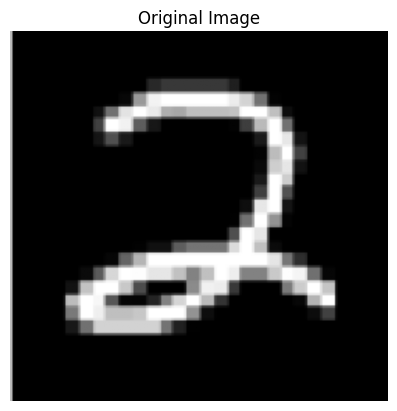

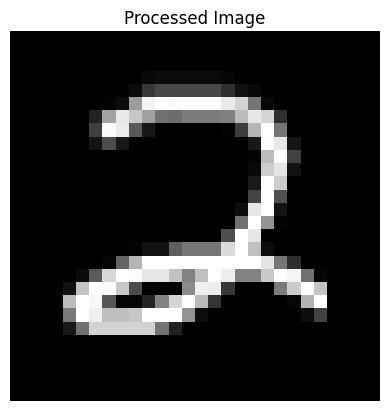

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted Digit: 2
Confidence: 0.99957365


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("digit_model.keras")

# Read image in grayscale
img = cv2.imread("/content/tttt.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found!")
else:
    # Show original image
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    # Resize to 28x28
    img = cv2.resize(img, (28, 28))

    # Normalize
    img = img.astype("float32") / 255.0

    # Show processed image
    plt.imshow(img, cmap="gray")
    plt.title("Processed Image")
    plt.axis("off")
    plt.show()

    # Reshape for CNN
    img = img.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(img)

    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction)

    print("Predicted Digit:", predicted_digit)
    print("Confidence:", confidence)